In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
df = pd.read_csv("india_housing_prices.csv")

df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [9]:
df.shape

(250000, 23)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

In [11]:
df.isnull().sum()

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

In [12]:
df.describe()

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


In [14]:
df.isnull().sum()

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

In [16]:
df.drop_duplicates(inplace=True)

print("Duplicates removed")

Duplicates removed


In [18]:
# numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# categorical columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values handled")

C:\Users\Windows 10\AppData\Local\Temp\ipykernel_16468\2712360606.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Windows 10\AppData\Local\Temp\ipykernel_16468\2712360606.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


Missing values handled


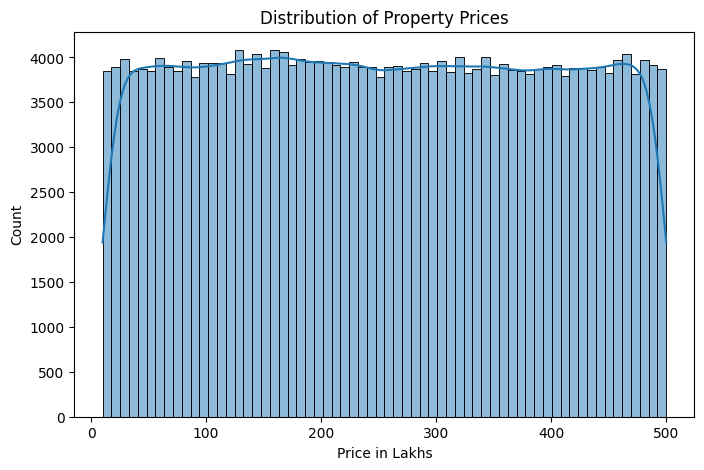

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df["Price_in_Lakhs"], kde=True)

plt.title("Distribution of Property Prices")
plt.xlabel("Price in Lakhs")
plt.ylabel("Count")

plt.show()

In [22]:
import os

output_path = r"C:\Users\Windows 10\Documents\LABMENTIX PROJECTS\outputs\charts"

os.makedirs(output_path, exist_ok=True)

In [4]:
output_path = r"C:\Users\Windows 10\Documents\LABMENTIX PROJECTS\outputs\charts"

os.makedirs(output_path, exist_ok=True)

In [6]:
df = pd.read_csv("india_housing_prices.csv")

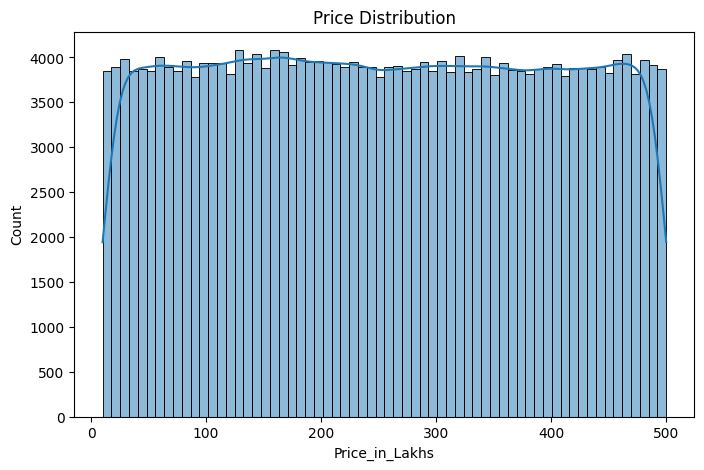

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price_in_Lakhs"], kde=True)
plt.title("Price Distribution")
plt.savefig(output_path + "/q1_price_distribution.png")
plt.show()

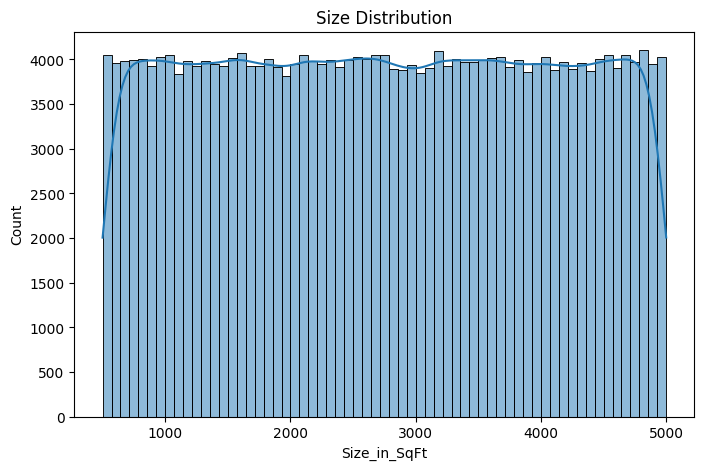

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["Size_in_SqFt"], kde=True)
plt.title("Size Distribution")
plt.savefig(output_path + "/q2_size_distribution.png")
plt.show()

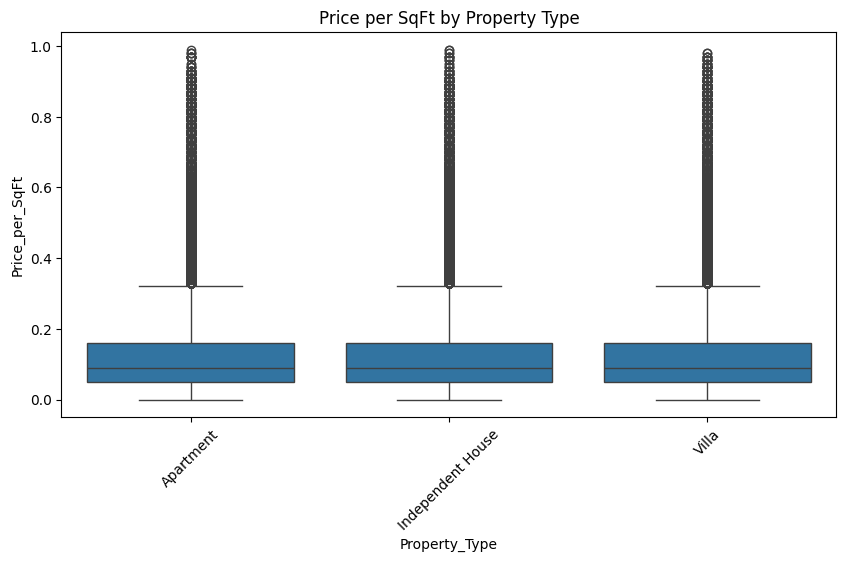

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Property_Type", y="Price_per_SqFt", data=df)
plt.xticks(rotation=45)
plt.title("Price per SqFt by Property Type")
plt.savefig(output_path + "/q3_price_by_type.png")
plt.show()

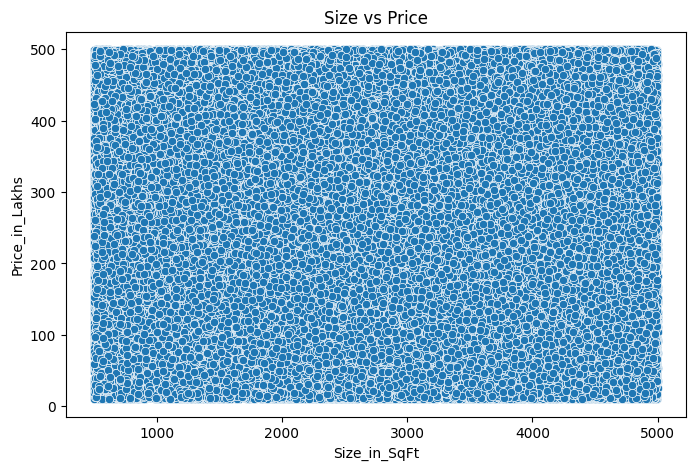

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Size_in_SqFt", y="Price_in_Lakhs", data=df)
plt.title("Size vs Price")
plt.savefig(output_path + "/q4_size_price_relation.png")
plt.show()

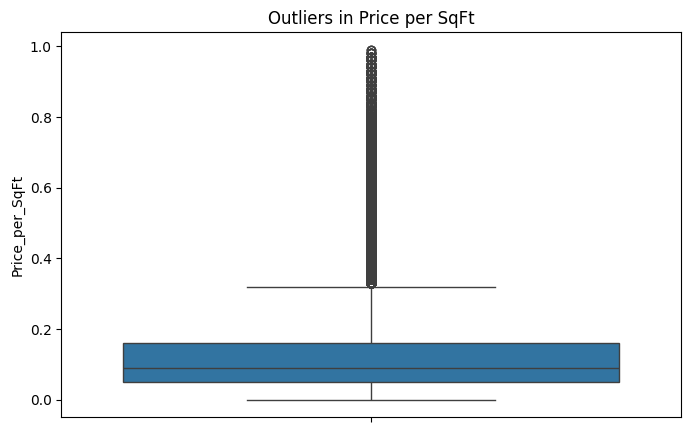

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(df["Price_per_SqFt"])
plt.title("Outliers in Price per SqFt")
plt.savefig(output_path + "/q5_outliers.png")
plt.show()

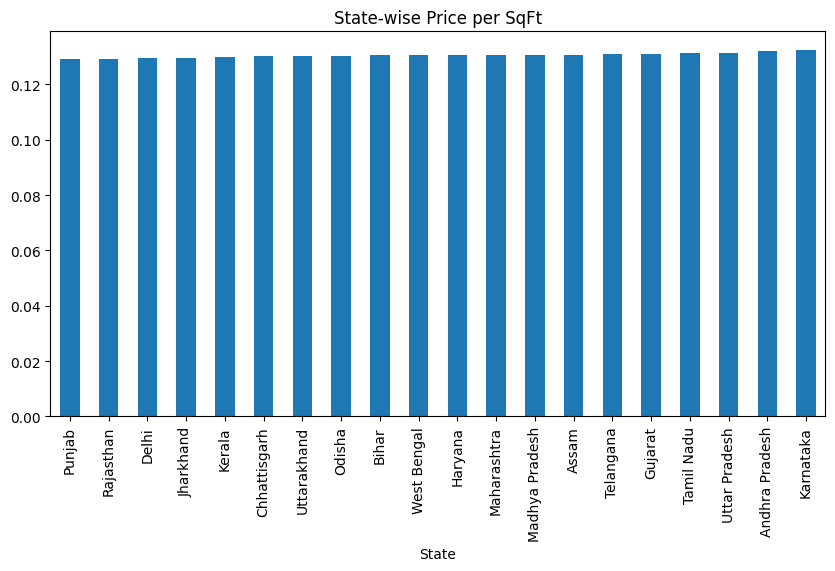

In [18]:
state = df.groupby("State")["Price_per_SqFt"].mean().sort_values()

state.plot(kind="bar", figsize=(10,5))
plt.title("State-wise Price per SqFt")
plt.savefig(output_path + "/q6_state_price.png")
plt.show()

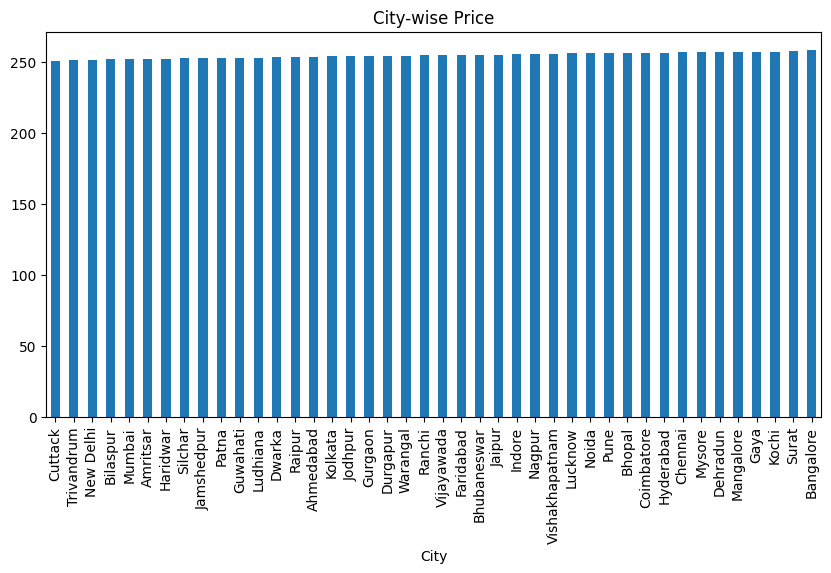

In [20]:
city = df.groupby("City")["Price_in_Lakhs"].mean().sort_values()

city.plot(kind="bar", figsize=(10,5))
plt.title("City-wise Price")
plt.savefig(output_path + "/q7_city_price.png")
plt.show()

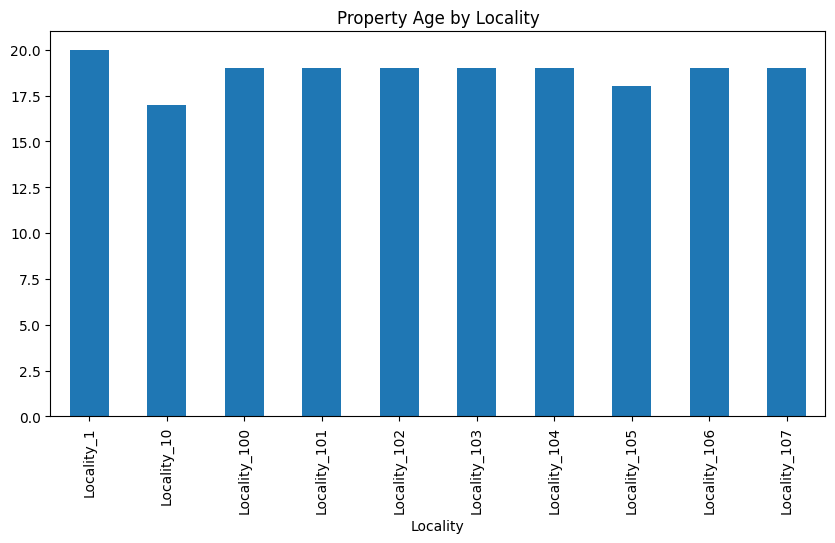

In [22]:
locality = df.groupby("Locality")["Age_of_Property"].median().head(10)

locality.plot(kind="bar", figsize=(10,5))
plt.title("Property Age by Locality")
plt.savefig(output_path + "/q8_locality_age.png")
plt.show()

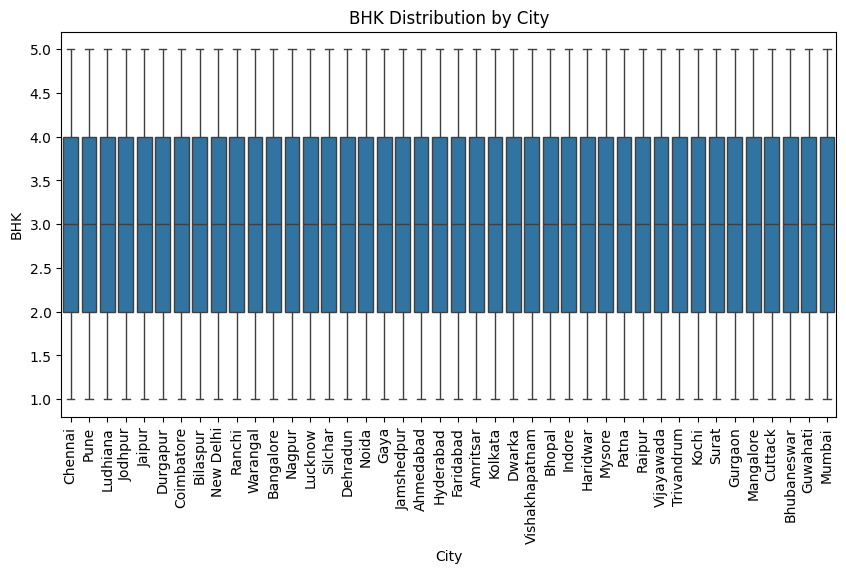

In [24]:
plt.figure(figsize=(10,5))
sns.boxplot(x="City", y="BHK", data=df)
plt.xticks(rotation=90)
plt.title("BHK Distribution by City")
plt.savefig(output_path + "/q9_bhk_city.png")
plt.show()

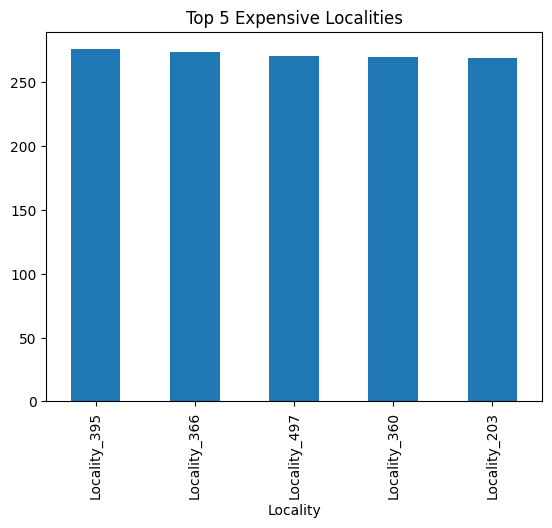

In [26]:
top_localities = df.groupby("Locality")["Price_in_Lakhs"].mean().sort_values(ascending=False).head(5)

top_localities.plot(kind="bar")
plt.title("Top 5 Expensive Localities")
plt.savefig(output_path + "/q10_top_localities.png")
plt.show()

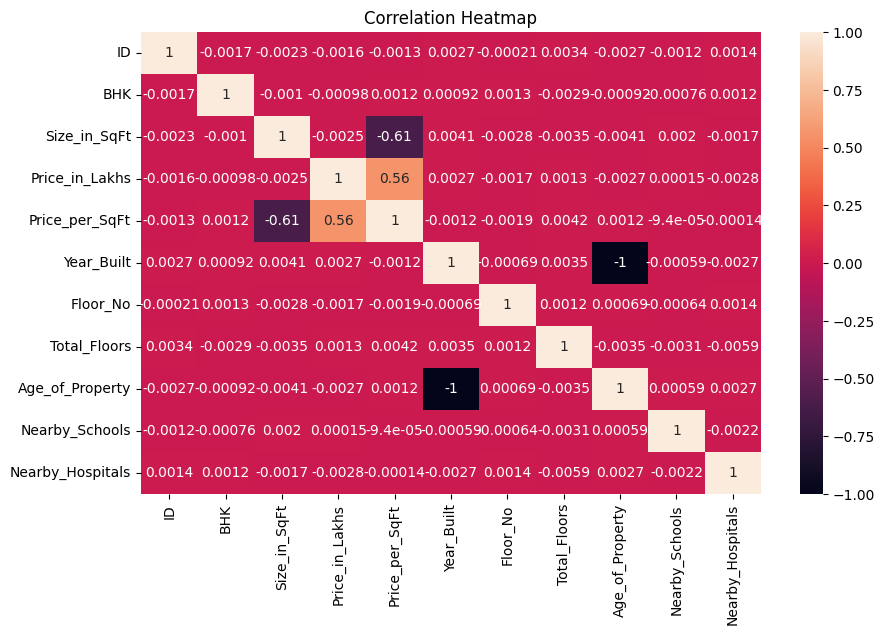

In [28]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.savefig(output_path + "/q11_corr.png")
plt.show()

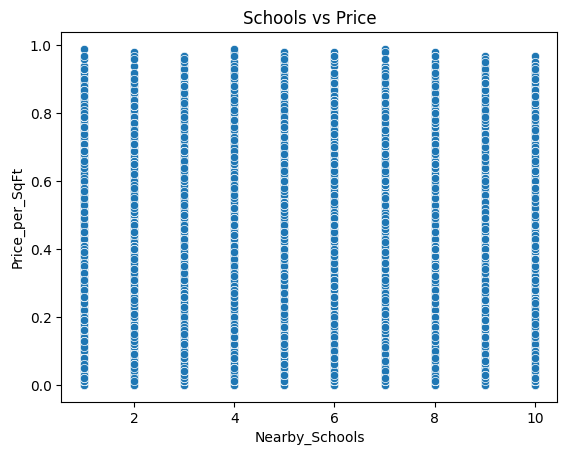

In [30]:
sns.scatterplot(x="Nearby_Schools", y="Price_per_SqFt", data=df)
plt.title("Schools vs Price")
plt.savefig(output_path + "/q12_schools.png")
plt.show()

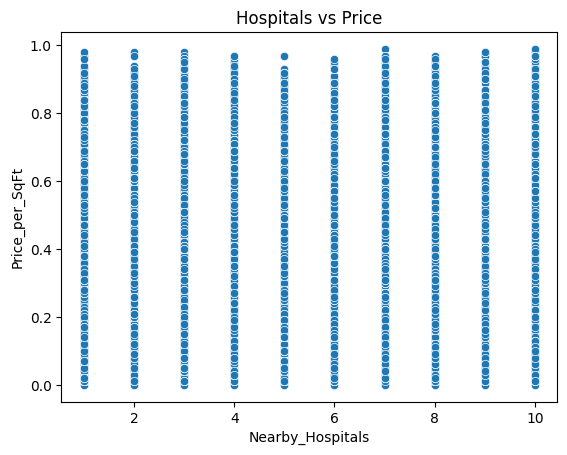

In [32]:
sns.scatterplot(x="Nearby_Hospitals", y="Price_per_SqFt", data=df)
plt.title("Hospitals vs Price")
plt.savefig(output_path + "/q13_hospitals.png")
plt.show()

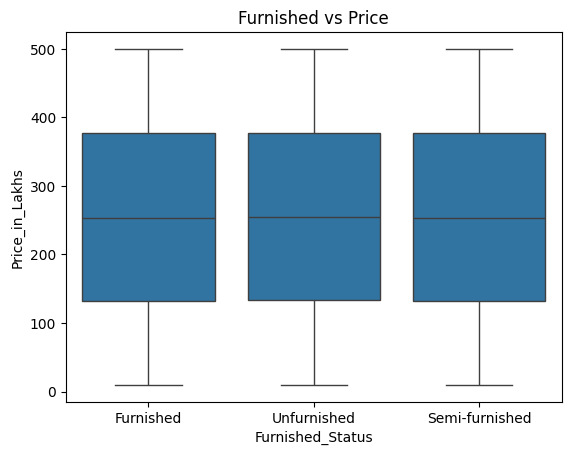

In [34]:
sns.boxplot(x="Furnished_Status", y="Price_in_Lakhs", data=df)
plt.title("Furnished vs Price")
plt.savefig(output_path + "/q14_furnished.png")
plt.show()

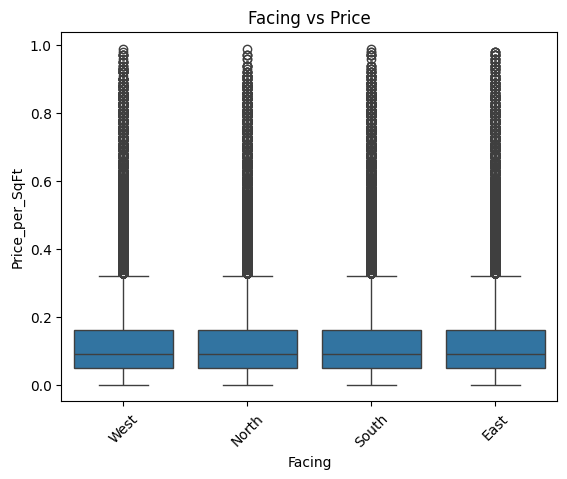

In [36]:
sns.boxplot(x="Facing", y="Price_per_SqFt", data=df)
plt.xticks(rotation=45)
plt.title("Facing vs Price")
plt.savefig(output_path + "/q15_facing.png")
plt.show()

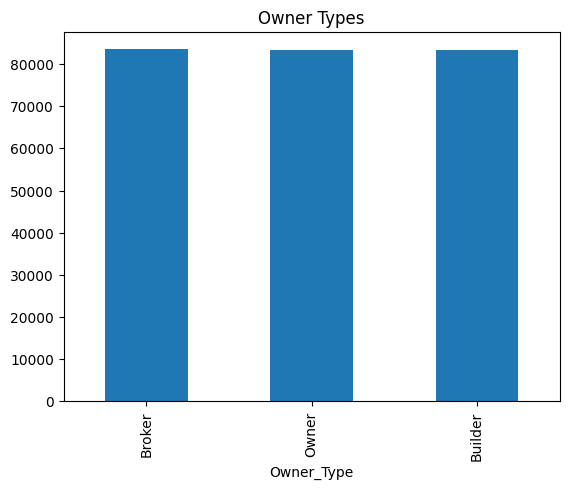

In [38]:
df["Owner_Type"].value_counts().plot(kind="bar")
plt.title("Owner Types")
plt.savefig(output_path + "/q16_owner.png")
plt.show()

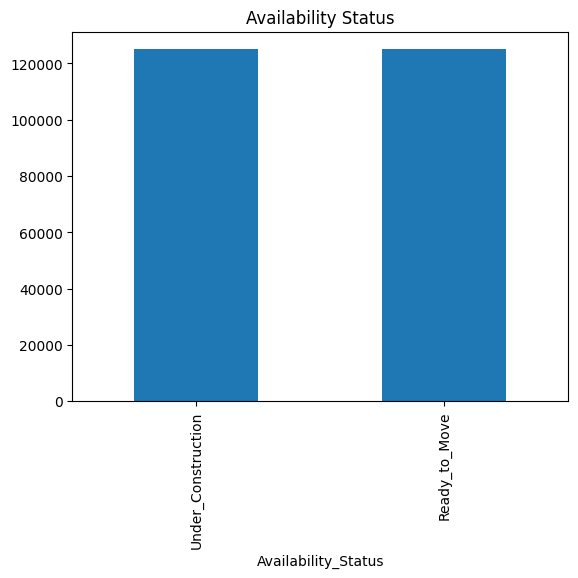

In [40]:
df["Availability_Status"].value_counts().plot(kind="bar")
plt.title("Availability Status")
plt.savefig(output_path + "/q17_availability.png")
plt.show()

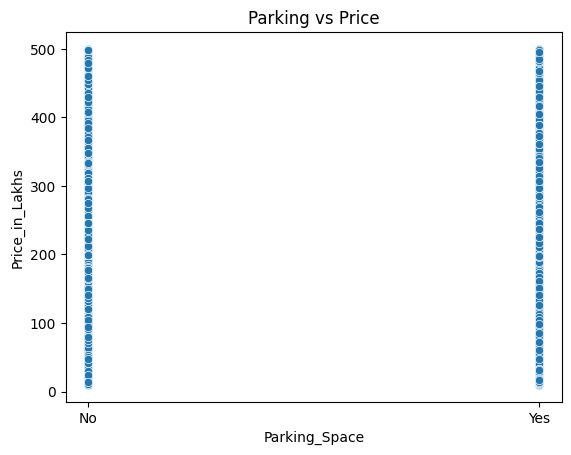

In [42]:
sns.scatterplot(x="Parking_Space", y="Price_in_Lakhs", data=df)
plt.title("Parking vs Price")
plt.savefig(output_path + "/q18_parking.png")
plt.show()

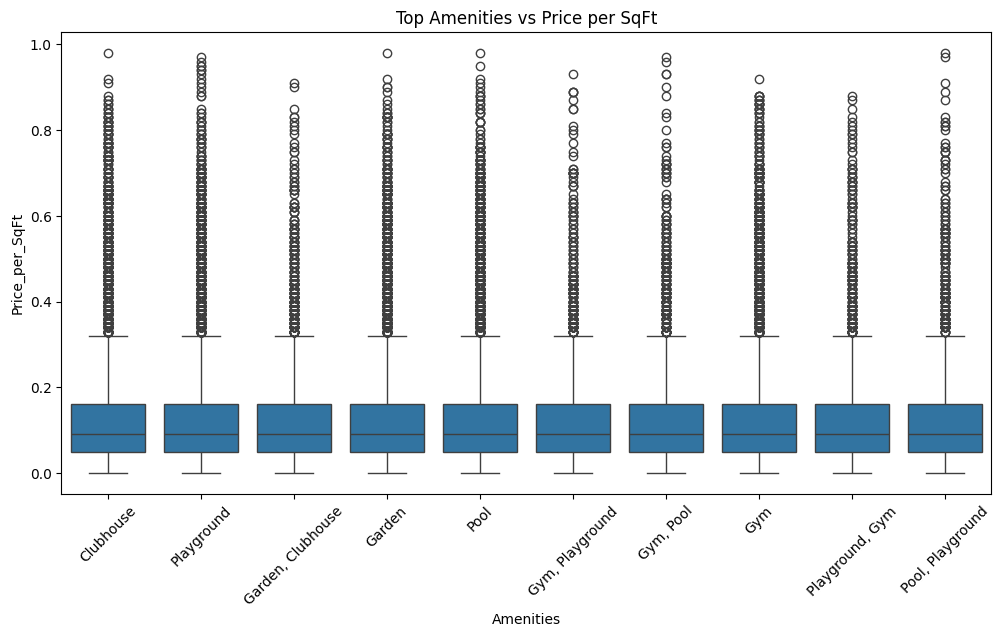

In [45]:
top_amenities = df["Amenities"].value_counts().head(10).index

filtered_df = df[df["Amenities"].isin(top_amenities)]

plt.figure(figsize=(12,6))

sns.boxplot(
    x="Amenities",
    y="Price_per_SqFt",
    data=filtered_df
)

plt.xticks(rotation=45)

plt.title("Top Amenities vs Price per SqFt")

plt.savefig(output_path + "/q19_amenities.png")

plt.show()

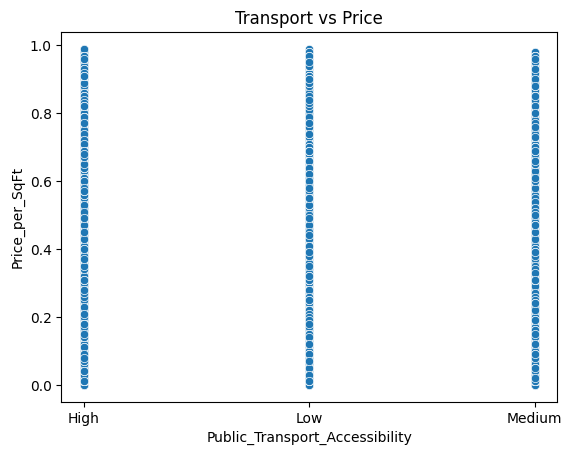

In [47]:
sns.scatterplot(x="Public_Transport_Accessibility", y="Price_per_SqFt", data=df)
plt.title("Transport vs Price")
plt.savefig(output_path + "/q20_transport.png")
plt.show()

In [48]:
df.to_csv("cleaned_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
